# Normlaized concentration response (single porosity, two-component model)

This notebook simulates the calibrated two-component model from `two_components/outputs/phase_exploitation/overall_best_refined_solution.csv` and reports the breakthrough curves in dimensionless form.

The dimensionless concentration is defined as:

`C_dim(t) = (C(t) - C0) / (C_inj - C0)`

For the linear single-porosity model this collapses out the absolute values of the background and injection concentrations, so the curves depend only on the fluid-flow parameters and the fracture retardation factor.

Three retardation factors are simulated in a single figure:

- `R_f = 1.0` -> conservative tracer
- `R_f = 1.5`
- `R_f = 3.0`

## 1) Imports

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2) Read calibrated parameters

In [2]:
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root))

from reactive_transport.simulation_options_2 import simulateDualPorosity

best_csv = repo_root / "two_components/outputs/phase_exploitation/overall_best_refined_solution.csv"
best_df = pd.read_csv(best_csv)

best_row = best_df.loc[best_df["best_J"].idxmin()]

mrt1_best = float(best_row["best_MRT1"])
mrt2_best = float(best_row["best_MRT2"])
pe1_best = float(best_row["best_Pe1"])
pe2_best = float(best_row["best_Pe2"])
fr1_best = float(best_row["best_fr1"])
fr2_best = float(best_row["best_fr2"])

best_df.head()

,basin_id,ref_run_idx,seed,best_MRT1,best_MRT2,best_Pe1,best_Pe2,best_fr1,best_fr2,best_J,nit,nfev,success,message
0,19,2,202,11.475848,48.819593,15.32661,2.034558,0.265815,0.671666,0.030909,59,5387,True,Optimization terminated successfully.


## 3) Define single-run model

In [3]:
def _rf_tag(rf):
    return f"{rf:.1f}".replace(".", "p")


def modelRELAP_single(
    t,
    mrt,
    pec,
    fracture_retardation,
    bckgrnd_conc,
    inj_concentration,
    inj_duration_hr,
):
    inj_concs = np.array([inj_concentration, bckgrnd_conc], dtype=float)
    inj_durs = np.cumsum(np.array([inj_duration_hr], dtype=float))
    dpParam = 0.0
    matrix_retardation = 1.0
    recRatio = 0.0
    wsCoef = 0.0

    return np.asarray(
        simulateDualPorosity(
            mrt,
            pec,
            fracture_retardation,
            t,
            bckgrnd_conc,
            inj_concs,
            inj_durs,
            dpParam,
            matrix_retardation,
            recRatio=recRatio,
            wsCoef=wsCoef,
            delay_time=0,
        ),
        dtype=float,
    )

## 4) Simulate dimensionless responses for `R_f = 1.0, 1.5, 3.0`

In [4]:
runs = [
    {"rf": 1.0, "c0": 0.0, "inj_concentration": 7.0},  # arbitrary; replace with desired values
    {"rf": 1.5, "c0": 22.0, "inj_concentration": 0.0},   # arbitrary; replace with desired values
    {"rf": 3.0, "c0": 30.0, "inj_concentration": 0.0},  # arbitrary; replace with desired values
]
inj_duration_hr = 1.5
t_plot = np.linspace(0.1, 130.0, 120)

results = []

for run in runs:
    rf = run["rf"]
    c0 = run["c0"]  # background concentration (mg/L)
    inj_concentration = run["inj_concentration"]

    c1_100 = modelRELAP_single(
        t_plot,
        mrt1_best,
        pe1_best,
        rf,
        c0,
        inj_concentration,
        inj_duration_hr,
    )
    c2_100 = modelRELAP_single(
        t_plot,
        mrt2_best,
        pe2_best,
        rf,
        c0,
        inj_concentration,
        inj_duration_hr,
    )

    c1_rel = c1_100 - c0
    c2_rel = c2_100 - c0
    c_eq_rel = fr1_best * c1_rel + fr2_best * c2_rel
    c_dim = c_eq_rel / (inj_concentration - c0)

    results.append({**run, "C_dim": c_dim})

results[0]["C_dim"][:5]

array([2.41906141e-31, 2.13422033e-10, 5.78786946e-06, 2.89990964e-04,
       2.75473922e-03])

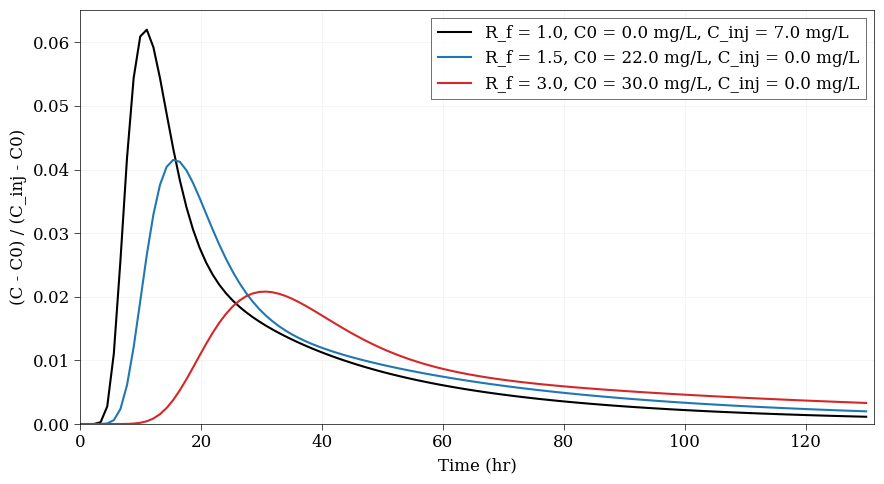

In [5]:
_pt = 1.5
_pt_hair = 0.5
font_size = 12
_grid_gray = "#F2F2F2"

run_colors = ["black", "#1f77b4", "#d62728"]

with plt.rc_context(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "pdf.fonttype": 42,
    }
):
    fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.set_axisbelow(True)
    ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

    for i, run in enumerate(results):
        label = (
            f"R_f = {run['rf']:.1f}, "
            f"C0 = {run['c0']:.1f} mg/L, "
            f"C_inj = {run['inj_concentration']:.1f} mg/L"
        )
        ax.plot(
            t_plot,
            run["C_dim"],
            color=run_colors[i],
            linewidth=_pt,
            label=label,
        )

    ax.set_xlabel("Time (hr)")
    ax.set_ylabel("(C - C0) / (C_inj - C0)")

    for side in ax.spines:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(_pt_hair)
        ax.spines[side].set_color("black")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=_pt_hair,
        colors="black",
        top=False,
        right=False,
    )

    y_max = max(np.max(r["C_dim"]) for r in results)
    ax.set_xlim(0, float(np.max(t_plot)) * 1.01)
    ax.set_ylim(0, float(y_max) * 1.05)

    leg = ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="black", fancybox=False)
    leg.get_frame().set_linewidth(_pt_hair)
    leg.get_frame().set_edgecolor("black")

    fig.tight_layout()
    fig.patch.set_linewidth(0)
    fig.patch.set_edgecolor("none")

    # fig.savefig(
    #     "../Figures/normalized_concentration_three_runs.pdf",
    #     facecolor="white",
    #     edgecolor="none",
    #     bbox_inches="tight",
    #     pad_inches=0.25,
    # )

    plt.show()

In [6]:
tabular_results_dir = repo_root / "tabular_results"
tabular_results_dir.mkdir(parents=True, exist_ok=True)

df_dim = pd.DataFrame({"time_hr": t_plot})

for i, run in enumerate(results, start=1):
    rf_tag = _rf_tag(run["rf"])
    c0_tag = f"{run['c0']:.1f}".replace(".", "p")
    cinj_tag = f"{run['inj_concentration']:.1f}".replace(".", "p")
    df_dim[f"C_dim_run{i}_Rf_{rf_tag}_C0_{c0_tag}_Cinj_{cinj_tag}"] = run["C_dim"]

out_xlsx_dim = tabular_results_dir / "normalized_concentration_three_runs.xlsx"
df_dim.to_excel(out_xlsx_dim, index=False)
out_xlsx_dim

PosixPath('/mnt/c/Users/mhesh/OneDrive - Texas Tech University/Texas Tech/Utah Forge Geothermal/Geothermics Paper/Code/tabular_results/normalized_concentration_three_runs.xlsx')